# Experiment 2: Diffusion Across Multiple Time Points
**Drug Modeled:** Lidocaine  
**Condition Tested:** Concentration profile evolution over clinically relevant time points  
**Research Question:** How does the Lidocaine concentration profile change 
across tissue depth as time progresses after administration?

## Background

Experiment 1 established the baseline concentration profile at a single 
time point. This experiment extends that model by examining how the profile 
evolves across multiple time points spanning the clinical onset window for 
Lidocaine anesthesia.

Lidocaine anesthesia onset is typically observed between 2 and 20 minutes 
after administration. Modeling the concentration profile at multiple time 
points within this window allows us to observe how drug penetration depth 
and surface concentration change over time.

With the normalized Gaussian solution, two effects are expected simultaneously:
- Peak concentration at the surface decreases as drug spreads outward
- The concentration profile flattens and penetrates deeper tissue over time

These two effects together determine the therapeutic window — the time period 
during which sufficient drug concentration exists at the target nerve depth.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('figures', exist_ok=True)

# ── Parameters ────────────────────────────────────────────────────────────────

# Diffusion coefficient — Lidocaine through biological membrane
# Source: University of Minnesota, NIH
D = 1.25e-8          # cm²/s

# Initial surface concentration — 2% Lidocaine solution
C0 = 20.0            # mg/mL

# Tissue depth range
x = np.linspace(0, 0.15, 1000)   # cm (0 to 1.5mm)

# Clinically relevant time points spanning Lidocaine onset window
times_min = [2, 5, 10, 20, 30, 60]       # minutes (for display)
times_sec = [t * 60 for t in times_min]  # seconds (for calculation)

# Color palette — one color per time point
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

In [2]:
# ── Normalized Gaussian Solution Across Time Points ───────────────────────────

profiles = []

for t in times_sec:
    normalization = 1 / np.sqrt(4 * np.pi * D * t)
    C = C0 * normalization * np.exp(-(x**2) / (4 * D * t))
    profiles.append(C)

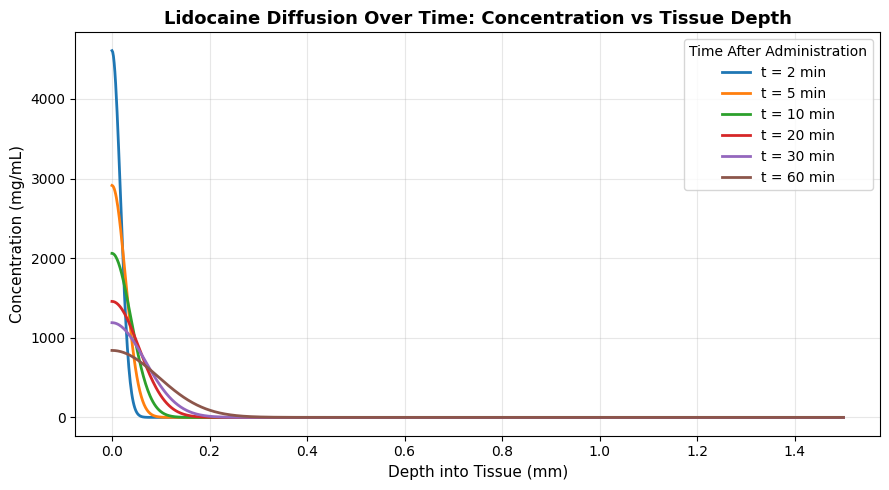

In [3]:
# ── Plot ──────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 5))

for i, (C, t_min) in enumerate(zip(profiles, times_min)):
    ax.plot(x * 10, C, color=colors[i], linewidth=2, label=f't = {t_min} min')

ax.set_title('Lidocaine Diffusion Over Time: Concentration vs Tissue Depth',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Depth into Tissue (mm)', fontsize=11)
ax.set_ylabel('Concentration (mg/mL)', fontsize=11)
ax.legend(fontsize=10, title='Time After Administration')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/exp02_time.png', dpi=150)
plt.show()

## Observations

- Surface concentration (x = 0) decreases progressively with time as drug 
  spreads into deeper tissue — this is the normalization factor in action
- Penetration depth increases with time — later time points show non-zero 
  concentration at greater depths
- The curves flatten and widen over time, reflecting drug redistribution 
  across a larger tissue volume
- By t = 60 minutes, concentration at depth is higher than at t = 2 minutes, 
  but surface concentration is substantially lower

## Interpretation

The time evolution of the concentration profile has direct clinical relevance. 
A physician administering topical Lidocaine is implicitly relying on this 
diffusion process — drug must penetrate to the target nerve depth before 
anesthesia takes effect.

The tradeoff revealed here is clinically important: as time passes, more drug 
reaches deeper tissue, but surface and shallow-tissue concentrations drop. 
This suggests there is an optimal time window for each target depth — too early 
and insufficient drug has reached the nerve, too late and concentration may 
have dropped below the therapeutic threshold.

Experiment 6 will quantify this window explicitly using the minimum effective 
concentration for Lidocaine nerve block.

## Next Experiment

Experiment 2 used a single fixed diffusion coefficient for all time points. 
Experiment 3 examines how sensitive drug penetration is to changes in D — 
modeling the effect of different tissue densities and drug formulations on 
Lidocaine delivery.